## Tratamiento de datos para clustering.

Para el entrenamiento de los modelos de clustering necesitamos obtener datos de los clientes para poder agruparlos según características de compra. Para ello vamos a realizar lo siguiente:

- Cargar el csv limpio para clustering.

- Prescindir de las variables innecesarias.

- Correciones en el tipado de las columnas.

- Generación de nuevas variables en base a las características de los clientes.

#### Librerías utilizadas.

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

#### Carga del csv limpio y visualización.

In [155]:
df = pd.read_csv('../output/data_limpio_clustering.csv')

Comprobamos que los datos son correctos.

In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 355996 entries, 0 to 355995
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    355996 non-null  int64  
 1   StockCode    355996 non-null  str    
 2   Description  355996 non-null  str    
 3   Quantity     355996 non-null  int64  
 4   InvoiceDate  355996 non-null  str    
 5   UnitPrice    355996 non-null  float64
 6   CustomerID   355996 non-null  float64
 7   Country      355996 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 21.7 MB


In [157]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


#### Variables necesarias.

Necesitamos características de los clientes para poderlos agrupar mediante los modelos de clustering. Por lo tanto nos quedaremos con las siguientes columnas:

- InvoiceNo: Para poder extraer relaciones entre el número de facturas y los clientes.

- StockCode: Para encontrar patrones entre los clientes y el tipo de productos comprados.

- Quantity: Para conocer la cantidad de productos que el cliente compra.

- InvoiceDate: Para conocer las fechas más frecuentes de compra para ese cliente.

- UnitPrice: Combinado con la cantidad para ver el poder de adquisición que tiene que cada cliente.

- CustomerID: Que permite identificar a cada cliente.

No tendremos en cuenta la descripción ya que no aporta nada y tampoco el País ya que sólo predomina el Reino Unido y puede generar inconsistencias.

In [158]:
df_transformado = df.copy()
df_transformado = df_transformado.drop(columns=['Description', 'Country'])
df_transformado.head(5)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0


#### Tipado de las columnas.

Como hemos visto anteriormente algunas columnas están mal tipdas. En este caso vamos a corregir CustomerID para que sea de tipo String ya que representa un identificador de cliente. Lo mismo para InvoiceNo. La fecha también se transforma a un formato más manejable y propio de esta.

In [159]:
df_transformado['InvoiceDate'] = pd.to_datetime(df_transformado['InvoiceDate'], format='%m/%d/%Y %H:%M')
df_transformado['InvoiceNo'] = df_transformado['InvoiceNo'].astype('string')
df_transformado['CustomerID'] = df_transformado['CustomerID'].astype('int64').astype('string')
df_transformado.info()
df_transformado.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 355996 entries, 0 to 355995
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    355996 non-null  string        
 1   StockCode    355996 non-null  str           
 2   Quantity     355996 non-null  int64         
 3   InvoiceDate  355996 non-null  datetime64[us]
 4   UnitPrice    355996 non-null  float64       
 5   CustomerID   355996 non-null  string        
dtypes: datetime64[us](1), float64(1), int64(1), str(1), string(2)
memory usage: 16.3 MB


,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850


#### Generación de nuevas variables.

Vamos a generar nuevas variables a partir de las columnas que tenemos para poder obtener características más relevantes de los clientes. Estas son:

- GastoTotal: Obtenemos el gasto total de cada cliente multiplicando la cantidad por el precio unitario.

- FrecuenciaCompra: Obtenemos la frecuencia de compra de cada cliente contando el número de facturas que tiene cada cliente.

- VariedadProductos: Obtenemos la variedad de productos que compra cada cliente contando el número de productos distintos que compra cada cliente.

- CantidadTotal: Obtenemos la cantidad total de productos que compra cada cliente sumando la cantidad de productos que compra cada cliente.

Primero agrupamos el dataframe por CustomerID para obtener las características de cada cliente y establecemos nuevas columnas para obtener estas características. 

In [160]:
df_agrupado = df_transformado.groupby('CustomerID').agg({
  'InvoiceNo': 'nunique',
  'StockCode': 'nunique',
  'Quantity': 'sum',
  'UnitPrice': 'mean',
  'InvoiceDate': 'nunique'
}).reset_index()
df_agrupado.head(5)

,CustomerID,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate
0,12347,7,98,1909,2.473254,7
1,12348,3,6,140,0.650000,3
2,12349,1,66,551,3.355303,1
3,12350,1,16,196,1.581250,1
4,12352,7,56,521,3.844133,7


Generamos las columnas finales que utilizaremos para el modelo de clustering.

In [161]:
fecha_min = df_transformado['InvoiceDate'].min()
fecha_max = df_transformado['InvoiceDate'].max()
dias_totales = (fecha_max - fecha_min).days

df_transformado = df_agrupado.copy()
df_transformado['Transacciones'] = df_transformado['InvoiceNo']
df_transformado['ProductosDistintos'] = df_transformado['StockCode']
df_transformado['GastoTotal'] = df_transformado['Quantity'] * df_transformado['UnitPrice']
df_transformado['FrecuenciaCompra'] = df_transformado['Transacciones'] / dias_totales

df_transformado.head(5)

,CustomerID,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Transacciones,ProductosDistintos,GastoTotal,FrecuenciaCompra
0,12347,7,98,1909,2.473254,7,7,98,4721.442722,0.018767
1,12348,3,6,140,0.650000,3,3,6,91.000000,0.008043
2,12349,1,66,551,3.355303,1,1,66,1848.771970,0.002681
3,12350,1,16,196,1.581250,1,1,16,309.925000,0.002681
4,12352,7,56,521,3.844133,7,7,56,2002.793467,0.018767


Borramos las columnas que ya no necesitamos.

In [162]:
df_transformado.drop(columns=['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'InvoiceDate'], inplace=True)
df_transformado.head(5)

,CustomerID,Transacciones,ProductosDistintos,GastoTotal,FrecuenciaCompra
0,12347,7,98,4721.442722,0.018767
1,12348,3,6,91.000000,0.008043
2,12349,1,66,1848.771970,0.002681
3,12350,1,16,309.925000,0.002681
4,12352,7,56,2002.793467,0.018767


#### Eliminación de valores extremos.

Primero visualizamos los valores extremos mediante diagramas de caja. 

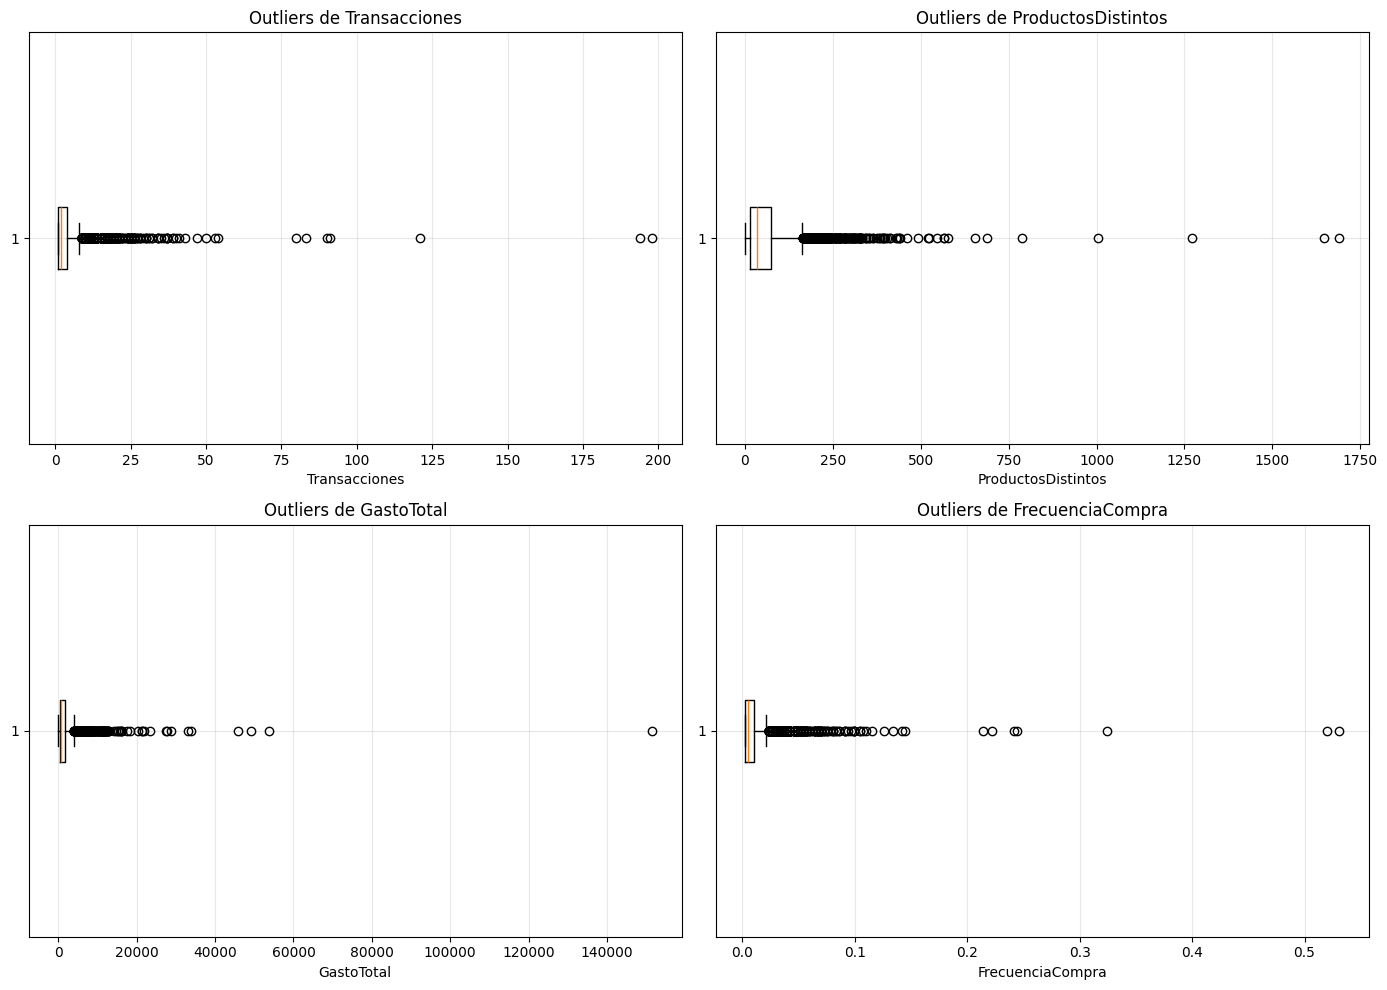

In [163]:
columnas_numericas = ['Transacciones', 'ProductosDistintos', 'GastoTotal', 'FrecuenciaCompra']
filas_antes_outliers = len(df_transformado)

limites = {}
for columna in columnas_numericas:
  Q1 = df_transformado[columna].quantile(0.25)
  Q3 = df_transformado[columna].quantile(0.75)
  IQR = Q3 - Q1
  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR
  limites[columna] = (limite_inferior, limite_superior)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, columna in enumerate(columnas_numericas):
  axes[idx].boxplot(df_transformado[columna], vert=False)
  axes[idx].set_title(f"Outliers de {columna}")
  axes[idx].set_xlabel(columna)
  axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Procedemos a la eliminación de outilers.

In [164]:
for columna in columnas_numericas:
  limite_inferior, limite_superior = limites[columna]
  df_transformado = df_transformado[(df_transformado[columna] >= limite_inferior) & (df_transformado[columna] <= limite_superior)]

print(f"Filas antes de eliminar outliers: {filas_antes_outliers}")
print(f"Filas después de eliminar outliers: {len(df_transformado)}")
print(f"Porcentaje de filas eliminadas: {((filas_antes_outliers - len(df_transformado)) / filas_antes_outliers) * 100:.2f}%")
df_transformado.describe()

Filas antes de eliminar outliers: 4208
Filas después de eliminar outliers: 3592
Porcentaje de filas eliminadas: 14.64%


,Transacciones,ProductosDistintos,GastoTotal,FrecuenciaCompra
count,3592.000000,3592.000000,3592.000000,3592.000000
mean,2.455178,38.409800,870.929871,0.006582
std,1.756302,33.787436,823.725205,0.004709
min,1.000000,1.000000,1.900000,0.002681
25%,1.000000,13.000000,271.681200,0.002681
50%,2.000000,28.000000,584.346817,0.005362
75%,3.000000,54.000000,1200.458901,0.008043
max,8.000000,163.000000,4016.666422,0.021448


#### Normalizado de los datos.

La transformación de los datos ha generado algunos valores más dispares, por lo que vamos a realizar una normalización. Utilizamos MinMaxScaler para escalar los datos entre 0 y 1 ya que hemos logrado eliminar los valores extremos y atípicos con la eliminación de outliers. Esto nos permitirá tener una mejor distribución de los datos para el entrenamiento de los modelos de clustering.

In [165]:
columnas_numericas = ['Transacciones', 'ProductosDistintos', 'GastoTotal', 'FrecuenciaCompra']
min_max_scaler = MinMaxScaler()
df_transformado[columnas_numericas] = min_max_scaler.fit_transform(df_transformado[columnas_numericas])
df_final = df_transformado.copy()
df_final.head(5)

,CustomerID,Transacciones,ProductosDistintos,GastoTotal,FrecuenciaCompra
1,12348,0.285714,0.030864,0.022193,0.285714
2,12349,0.000000,0.401235,0.460020,0.000000
3,12350,0.000000,0.092593,0.076723,0.000000
4,12352,0.857143,0.339506,0.498384,0.857143
5,12353,0.000000,0.018519,0.029790,0.000000


In [166]:
df_final.describe()

,Transacciones,ProductosDistintos,GastoTotal,FrecuenciaCompra
count,3592.000000,3592.000000,3592.000000,3592.000000
mean,0.207883,0.230925,0.216458,0.207883
std,0.250900,0.208564,0.205174,0.250900
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.074074,0.067197,0.000000
50%,0.142857,0.166667,0.145076,0.142857
75%,0.285714,0.327160,0.298538,0.285714
max,1.000000,1.000000,1.000000,1.000000


#### Exportar el dataframe transformado.

In [167]:
import os
os.makedirs('../output/clustering', exist_ok=True)

df_final.to_csv('../output/clustering/data_transformado_clustering.csv', index=False, encoding='ISO-8859-1')
print(f"Dataset de clustering exportado: {len(df_final)} filas")
print("Archivo: ../output/clustering/data_transformado_clustering.csv")

Dataset de clustering exportado: 3592 filas
Archivo: ../output/clustering/data_transformado_clustering.csv
